In [3]:
!pip install -r ../requirements.txt

  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
  Using cached shapely-2.1.2-cp313-cp313-win_amd64.whl.metadata (7.1 kB)
  Using cached pyproj-3.7.2-cp313-cp313-win_amd64.whl.metadata (31 kB)
  Using cached pyogrio-0.12.1-cp313-cp313-win_amd64.whl.metadata (6.0 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached geopandas-1.1.3-py3-none-any.whl (342 kB)
Using cached shapely-2.1.2-cp313-cp313-win_amd64.whl (1.7 MB)
Using cached pyproj-3.7.2-cp313-cp313-win_amd64.whl (6.3 MB)
Using cached pyogrio-0.12.1-cp313-cp313-win_amd64.whl (22.9 MB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)

   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [sha


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_parquet("../data/processed/PFOS.parquet")

print(gdf.shape)
gdf.head()

(22846, 4)


,lat,lon,value,geometry
0,-21.364356,55.733356,11.700000,POINT (55.73336 -21.36436)
1,-21.354096,55.623506,0.500000,POINT (55.62351 -21.3541)
2,-21.330124,55.487014,0.783333,POINT (55.48701 -21.33012)
3,-21.325085,55.474879,2.342857,POINT (55.47488 -21.32508)
4,-21.310517,55.468648,0.800000,POINT (55.46865 -21.31052)


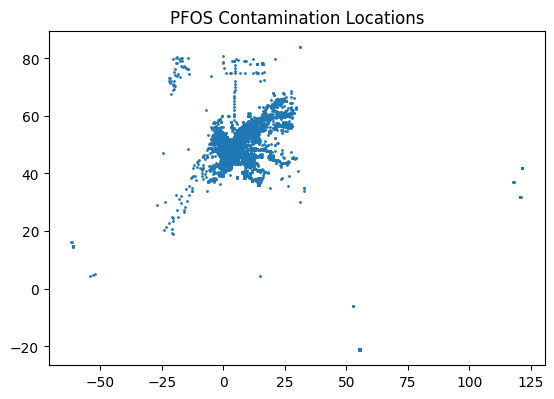

In [5]:
gdf.plot(markersize=1)
plt.title("PFOS Contamination Locations")
plt.show()

In [6]:
from sklearn.cluster import DBSCAN

coords = gdf[["lat","lon"]]

db = DBSCAN(eps=0.5, min_samples=10)
gdf["cluster"] = db.fit_predict(coords)

print(gdf["cluster"].value_counts())

cluster
 10    20754
-1       977
 29      113
 30       99
 22       84
 9        79
 0        51
 6        50
 32       49
 2        48
 26       39
 24       39
 7        37
 14       37
 8        36
 20       31
 16       29
 4        23
 33       22
 5        21
 18       21
 19       20
 15       17
 17       17
 25       16
 27       15
 3        14
 35       13
 13       13
 11       12
 1        11
 21       11
 23       11
 31       11
 12       10
 34       10
 28        6
Name: count, dtype: int64


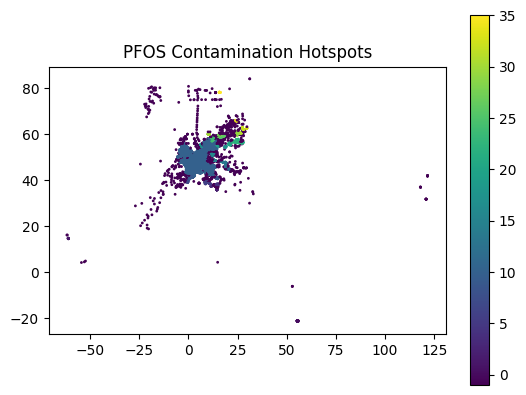

In [7]:
gdf.plot(column="cluster", legend=True, markersize=1)
plt.title("PFOS Contamination Hotspots")
plt.show()